In [1]:
!python -m spacy download el_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 29.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('el_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [2]:
import pandas as pd
%matplotlib inline
import numpy as np
import glob
from sklearn.feature_extraction.text import CountVectorizer
from datetime import datetime
import matplotlib.pyplot as plt

In [3]:
filepath = 'https://raw.githubusercontent.com/datajour-gr/DataJournalism/main/Bachelor%20Lessons%202023/Lesson%2010/NRC_GREEK_Translated_6_2020.csv'

In [4]:
emolex_df = pd.read_csv(filepath)
emolex_df

,word,Positive,Negative,Anger,Anticipation,Disgust,Fear,Joy,Sadness,Surprise,Trust
0,αφεση,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ενορκη βεβαιωση,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,εχοντας,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,εχω,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,οριο,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
13166,ουρλιασμα,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
13167,κροκος αυγου,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13168,νεοτερος,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13169,ζεφυρος,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
emolex_df = emolex_df.drop_duplicates(subset=['word'])
emolex_df = emolex_df.dropna()
emolex_df.reset_index(inplace = True, drop=True)

In [6]:
import spacy

In [7]:
nlp = spacy.load('el_core_news_sm')

In [8]:
from google.colab import drive
drive.mount ('/content/gdrive')

Mounted at /content/gdrive


In [9]:
short_tanea_df = pd.read_csv('/content/gdrive/MyDrive/Colab Notebooks/Notebooks εργασίας/TA NEA/short_tanea_df.csv')
short_tanea_df

,date,full_text,year,month,day,hour
0,2026-06-09 16:39:00,Έντονη κριτική στην κυβέρνησημε αφορμή τις δηλ...,2026,6,9,16
1,2026-06-07 16:38:00,Έντονους κραδασμούς στο κυβερνητικό στρατόπεδο...,2026,6,7,16
2,2026-06-04 13:20:00,Για τηστάση της κυβέρνησης μπροστά στο αίτημα ...,2026,6,4,13
3,2026-06-04 12:24:00,Νέα δεδομένα στηνπολύκροτη υπόθεση των τηλεφων...,2026,6,4,12
4,2026-06-02 17:03:00,Αίτημαγια ακρόαση τωνΤαλ ΝτίλιανκαιΓρηγόρη Δημ...,2026,6,2,17
...,...,...,...,...,...,...
136,2025-10-22 17:47:00,Μετά την ολοκλήρωση της κατάθεσης του στη δίκη...,2025,10,22,17
137,2025-08-24 18:27:00,Μια νέα τεχνολογία υποκλοπής φέρνει στο προσκή...,2025,8,24,18
138,2025-07-22 12:04:00,Στο δικαστικό προσκήνιο επανέρχεται η υπόθεση ...,2025,7,22,12
139,2025-02-11 14:28:00,Με το σκεπτικό ότι η υπόθεση των τηλεφωνικών υ...,2025,2,11,14


In [10]:
short_tanea_df.isna().sum()

,0
date,0
full_text,0
year,0
month,0
day,0
hour,0


In [11]:
vec = CountVectorizer(analyzer = 'word', vocabulary = emolex_df.word,
                      lowercase=False,
                      strip_accents = 'unicode',
                      stop_words= list(nlp.Defaults.stop_words),
                      ngram_range=(1, 2))

In [12]:
matrix = vec.fit_transform(short_tanea_df['full_text'])
vocab = vec.get_feature_names_out()
wordcount_df = pd.DataFrame(matrix.toarray(), columns=vocab)
wordcount_df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['αδιακοπα', 'ακομα', 'ακομη', 'ακριβως', 'αλλα', 'αλλαχου', 'αλλες', 'αλλη', 'αλλην', 'αλλης', 'αλλιως', 'αλλιωτικα', 'αλλο', 'αλλοι', 'αλλοιως', 'αλλοιωτικα', 'αλλον', 'αλλος', 'αλλοτε', 'αλλου', 'αλλους', 'αλλων', 'αμα', 'αμεσα', 'αμεσως', 'ανα', 'αναμεσα', 'αναμεταξυ', 'ανευ', 'αντι', 'αντιπερα', 'αντις', 'ανω', 'ανωτερω', 'αξαφνα', 'απεναντι', 'απο', 'αποψε', 'αρα', 'αραγε', 'αρκετα', 'αρκετες', 'αρχικα', 'αυριο', 'αυτα', 'αυτες', 'αυτη', 'αυτην', 'αυτης', 'αυτο', 'αυτοι', 'αυτον', 'αυτος', 'αυτου', 'αυτους', 'αυτων', 'αφοτου', 'αφου', 'βεβαια', 'βεβαιοτατα', 'γιατι', 'γρηγορα', 'γυρω', 'δεινα', 'δεξια', 'δηθεν', 'δηλαδη', 'διαρκως', 'δικα', 'δικο', 'δικοι', 'δικος', 'δικου', 'δικους', 'διολου', 'διπλα', 'διχως', 'εαν', 'εαυτο', 'εαυτον', 'εαυτου', 'εαυτους', 'εαυτων', 'εγιναν', 'εγινε',

,αφεση,ενορκη βεβαιωση,εχοντας,εχω,οριο,ορμος,υδρα,αγια τραπεζα,αμην,απατσι,...,κλητηριο ενταλμα,κατειργασμενος,μαγια,κιτρινο,κιτρινιζω,ουρλιασμα,κροκος αυγου,νεοτερος,ζεφυρος,ζουμ
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [13]:
wordcount_df.shape

(141, 13161)

In [14]:
# Φτιάξε μια λίστα με positive words
positive_words = emolex_df[emolex_df.Positive == 1]['word']

# Φτιάξε μια λίστα με negative words
negative_words = emolex_df[emolex_df.Negative == 1]['word']

# Φτιάξε μια λίστα με anger words
angry_words = emolex_df[emolex_df.Anger == 1]['word']

# Φτιάξε μια λίστα με anticipation words
anticipation_words = emolex_df[emolex_df.Anticipation == 1]['word']

# Φτιάξε μια λίστα με disgust words
disgust_words = emolex_df[emolex_df.Disgust == 1]['word']

# Φτιάξε μια λίστα με fear words
fear_words = emolex_df[emolex_df.Fear == 1]['word']

# Φτιάξε μια λίστα με joy words
joy_words = emolex_df[emolex_df.Joy == 1]['word']

# Φτιάξε μια λίστα με sadness words
sadness_words = emolex_df[emolex_df.Sadness == 1]['word']

# Φτιάξε μια λίστα με surprise words
surprise_words = emolex_df[emolex_df.Surprise == 1]['word']

# Φτιάξε μια λίστα με trust words
trust_words = emolex_df[emolex_df.Trust == 1]['word']

In [15]:
wordcount_df[positive_words].head()

,αφεση,αμην,αυγουστος,γαμηλιο ταξιδι,διευθυντρια σχολειου,δημοκρατια,επικοινωνω,εκκλησια,εν τω μεταξυ,ευαγγελιο,...,αναμφιβολως,ανυπερβατος,ανηφορικος δρομος,βελουδενιος,δικαιωσε,ζωτικης σημασιας,αδιαβροχος,καλωσορισατε,απροσδοκητα ευρημα,νεοτερος
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
wordcount_df[positive_words].sum(axis=1)

,0
0,13
1,12
2,4
3,10
4,26
...,...
136,6
137,13
138,11
139,5


In [17]:
short_tanea_df['anger'] = wordcount_df[angry_words].sum(axis=1)

short_tanea_df['positive'] = wordcount_df[positive_words].sum(axis=1)

short_tanea_df['joy'] = wordcount_df[joy_words].sum(axis=1)

short_tanea_df['disgust'] = wordcount_df[disgust_words].sum(axis=1)

short_tanea_df['surprise'] = wordcount_df[surprise_words].sum(axis=1)

short_tanea_df['trust'] = wordcount_df[trust_words].sum(axis=1)

short_tanea_df['anticipation'] = wordcount_df[anticipation_words].sum(axis=1)

short_tanea_df['sadness'] = wordcount_df[sadness_words].sum(axis=1)

short_tanea_df['negative'] = wordcount_df[negative_words].sum(axis=1)

short_tanea_df['fear'] = wordcount_df[fear_words].sum(axis=1)

In [18]:
short_tanea_df

,date,full_text,year,month,day,hour,anger,positive,joy,disgust,surprise,trust,anticipation,sadness,negative,fear
0,2026-06-09 16:39:00,Έντονη κριτική στην κυβέρνησημε αφορμή τις δηλ...,2026,6,9,16,8,13,2,7,9,8,9,12,20,13
1,2026-06-07 16:38:00,Έντονους κραδασμούς στο κυβερνητικό στρατόπεδο...,2026,6,7,16,5,12,2,6,6,7,10,11,16,9
2,2026-06-04 13:20:00,Για τηστάση της κυβέρνησης μπροστά στο αίτημα ...,2026,6,4,13,3,4,0,2,2,7,2,4,6,4
3,2026-06-04 12:24:00,Νέα δεδομένα στηνπολύκροτη υπόθεση των τηλεφων...,2026,6,4,12,6,10,0,2,4,10,3,5,17,11
4,2026-06-02 17:03:00,Αίτημαγια ακρόαση τωνΤαλ ΝτίλιανκαιΓρηγόρη Δημ...,2026,6,2,17,8,26,4,3,6,22,10,15,26,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,2025-10-22 17:47:00,Μετά την ολοκλήρωση της κατάθεσης του στη δίκη...,2025,10,22,17,1,6,3,1,2,4,3,3,7,2
137,2025-08-24 18:27:00,Μια νέα τεχνολογία υποκλοπής φέρνει στο προσκή...,2025,8,24,18,9,13,2,7,1,11,7,3,12,6
138,2025-07-22 12:04:00,Στο δικαστικό προσκήνιο επανέρχεται η υπόθεση ...,2025,7,22,12,4,11,3,4,6,12,9,2,10,9
139,2025-02-11 14:28:00,Με το σκεπτικό ότι η υπόθεση των τηλεφωνικών υ...,2025,2,11,14,1,5,1,2,3,4,3,3,5,4


#Resample

In [19]:
short_tanea_df['year'] = pd.DatetimeIndex(short_tanea_df['date']).year.astype('Int64')
short_tanea_df['month'] = pd.DatetimeIndex(short_tanea_df['date']).month.astype('Int64')
short_tanea_df['day'] = pd.DatetimeIndex(short_tanea_df['date']).day.astype('Int64')
short_tanea_df['hour'] = pd.DatetimeIndex(short_tanea_df['date']).hour.astype('Int64')
short_tanea_df

,date,full_text,year,month,day,hour,anger,positive,joy,disgust,surprise,trust,anticipation,sadness,negative,fear
0,2026-06-09 16:39:00,Έντονη κριτική στην κυβέρνησημε αφορμή τις δηλ...,2026,6,9,16,8,13,2,7,9,8,9,12,20,13
1,2026-06-07 16:38:00,Έντονους κραδασμούς στο κυβερνητικό στρατόπεδο...,2026,6,7,16,5,12,2,6,6,7,10,11,16,9
2,2026-06-04 13:20:00,Για τηστάση της κυβέρνησης μπροστά στο αίτημα ...,2026,6,4,13,3,4,0,2,2,7,2,4,6,4
3,2026-06-04 12:24:00,Νέα δεδομένα στηνπολύκροτη υπόθεση των τηλεφων...,2026,6,4,12,6,10,0,2,4,10,3,5,17,11
4,2026-06-02 17:03:00,Αίτημαγια ακρόαση τωνΤαλ ΝτίλιανκαιΓρηγόρη Δημ...,2026,6,2,17,8,26,4,3,6,22,10,15,26,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136,2025-10-22 17:47:00,Μετά την ολοκλήρωση της κατάθεσης του στη δίκη...,2025,10,22,17,1,6,3,1,2,4,3,3,7,2
137,2025-08-24 18:27:00,Μια νέα τεχνολογία υποκλοπής φέρνει στο προσκή...,2025,8,24,18,9,13,2,7,1,11,7,3,12,6
138,2025-07-22 12:04:00,Στο δικαστικό προσκήνιο επανέρχεται η υπόθεση ...,2025,7,22,12,4,11,3,4,6,12,9,2,10,9
139,2025-02-11 14:28:00,Με το σκεπτικό ότι η υπόθεση των τηλεφωνικών υ...,2025,2,11,14,1,5,1,2,3,4,3,3,5,4


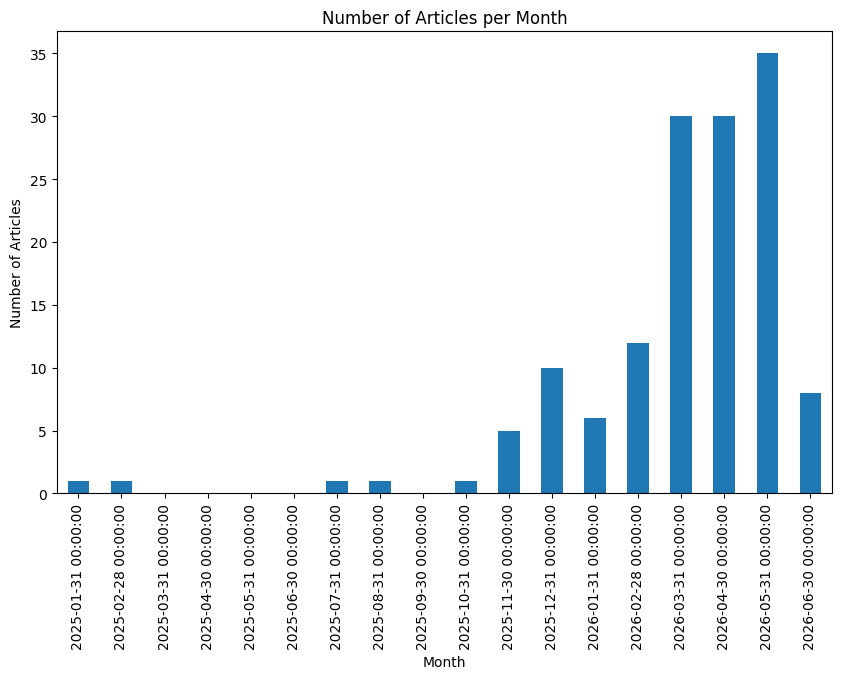

In [21]:
short_tanea_df['date'] = pd.to_datetime(short_tanea_df['date'])
short_tanea_df.set_index('date', inplace=True)
short_tanea_df['full_text'].resample('ME').count().plot(kind='bar', figsize=(10, 6))
plt.title('Number of Articles per Month')
plt.xlabel('Month')
plt.ylabel('Number of Articles')
plt.show()

Text(0.5, 1.0, 'Text length over time')

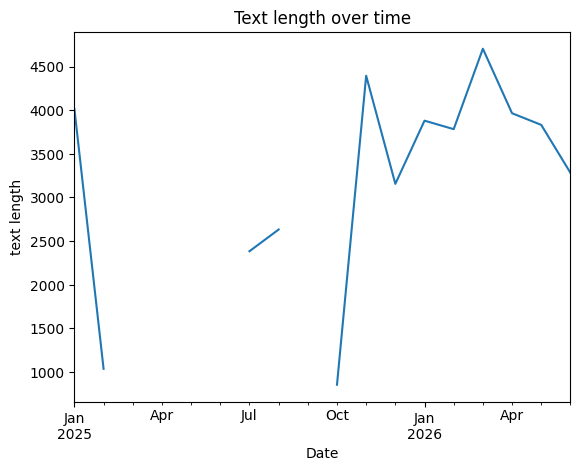

In [40]:
import matplotlib.pyplot as plt
short_tanea_df['full_text'].str.len().resample('ME').mean().plot()
plt.xlabel("Date")
plt.ylabel("text length")
plt.title("Text length over time")

<Axes: ylabel='date'>

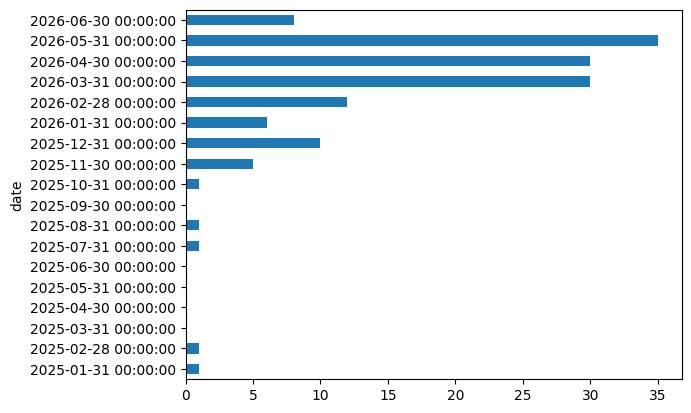

In [23]:
short_tanea_df['full_text'].resample('ME').count().plot(kind='barh')

<Axes: xlabel='date'>

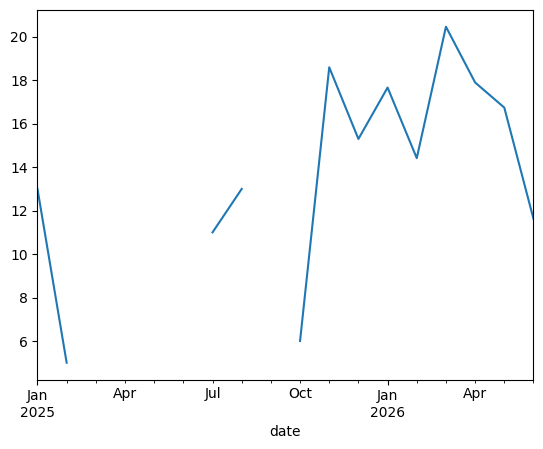

In [24]:
short_tanea_df['positive'].resample('ME').mean().plot()

<Axes: xlabel='date'>

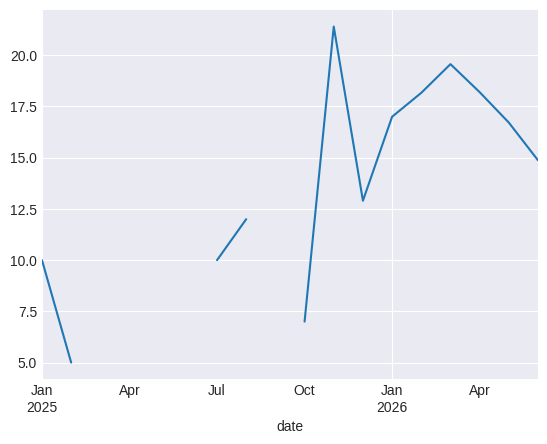

In [ ]:
short_tanea_df['negative'].resample('ME').mean().plot()

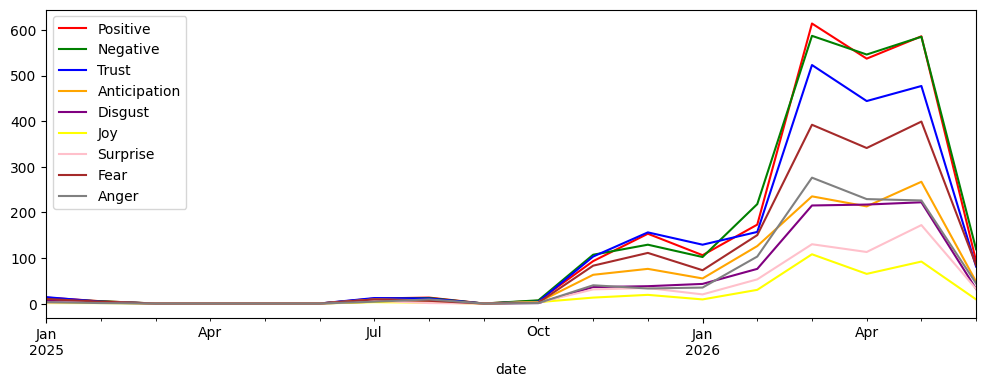

In [ ]:
ax = short_tanea_df['positive'].resample('ME').sum().plot(figsize=(12,4), color = 'red', label='Positive')
short_tanea_df['negative'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'green', label='Negative')
short_tanea_df['trust'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'blue', label='Trust')
short_tanea_df['anticipation'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'orange', label='Anticipation')
short_tanea_df['disgust'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'purple', label='Disgust')
short_tanea_df['joy'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'yellow', label='Joy')
short_tanea_df['surprise'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'pink', label='Surprise')
short_tanea_df['fear'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'brown', label='Fear')
short_tanea_df['anger'].resample('ME').sum().plot(figsize=(12,4), ax = ax, color = 'grey', label='Anger')
ax.legend()

<Axes: xlabel='date'>

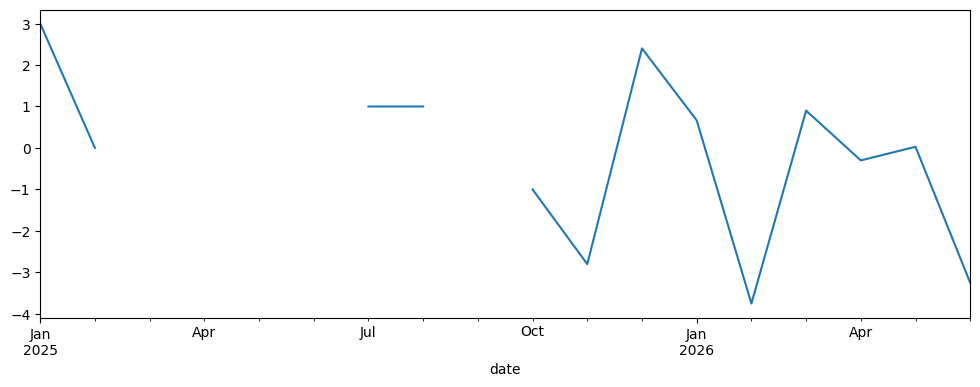

In [ ]:
short_tanea_df['pos/neg'] = short_tanea_df['positive'] - short_tanea_df['negative']
short_tanea_df['pos/neg'].resample('ME').mean().plot(figsize=(12,4))

#Polarity positivity negativity

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')

<Axes: xlabel='date'>

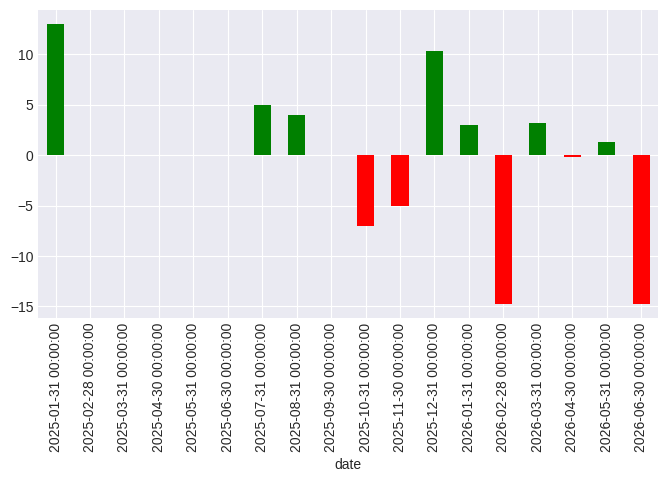

In [ ]:
short_tanea_df['(-)αρνητικότητα | θετικότητα(+)'] = short_tanea_df.positive*100//short_tanea_df[['positive','negative']].sum(
        axis=1) - short_tanea_df.negative*100//short_tanea_df[['positive','negative']].sum(axis=1)

short_tanea_df['(-)αρνητικότητα | θετικότητα(+)'].resample('ME').mean().plot(kind='bar',
                                                                               color=(short_tanea_df['(-)αρνητικότητα | θετικότητα(+)'].resample('ME').mean()>0
                                                                               ).map({True: 'g', False: 'r'}), figsize=(8,4))

In [ ]:
df_filtered = short_tanea_df[(short_tanea_df['(-)αρνητικότητα | θετικότητα(+)'] == short_tanea_df['(-)αρνητικότητα | θετικότητα(+)'].max()) |
                  (short_tanea_df['(-)αρνητικότητα | θετικότητα(+)'] == short_tanea_df['(-)αρνητικότητα | θετικότητα(+)'].min())
                  ]
df_filtered.reset_index()[['date', 'positive', 'negative', '(-)αρνητικότητα | θετικότητα(+)']]

,date,positive,negative,(-)αρνητικότητα | θετικότητα(+)
0,2026-05-19 15:11:00,1,5,-67
1,2025-12-04 15:23:00,9,3,50


In [ ]:
short_tanea_df.loc['2026-05-19 15:11:00']['full_text']

'«Η απόφαση του Εισαγγελέα του Αρείου Πάγου, κ. Τζαβέλλα,να αρνηθεί να προσέλθει ενώπιον της Επιτροπής Θεσμών και Διαφάνειας, είναι ενδεικτική της αδυναμίας του να αιτιολογήσει την απόφαση του να μην ανασύρει την υπόθεση από το αρχείο» τονίζει σε ανακοίνωσή του τοΠΑΣΟΚκαι προσθέτει ότι «Η επίκληση της αρχής της διάκρισης των εξουσιών δεν πείθει κανέναν. Αντιθέτως, η απόφαση της αρχειοθέτησης είναι αυτή που έχει δημιουργήσει σε όλη την κοινωνία την αίσθηση της κατάργησης στην πράξη της διάκρισης των εξουσιών».\n«Δεν υπήρξαν αντίστοιχες ευαισθησίες, όταν αρνήθηκε να εξαιρεθεί ως πρώην εποπτεύων της ΕΥΠ και επέλεξε να είναι και ελεγκτής και ελεγχόμενος στο σκάνδαλο των παράνομων παρακολουθήσεων.\xa0Ζούμε αλλεπάλληλες σκηνές στο έργο της συγκάλυψης. Αυτή η παρακμή θα τελειώσει με την πολιτική αλλαγή» καταλήγει η ανακοίνωση.'

In [ ]:
short_tanea_df.loc['2025-12-04 15:23:00']['full_text']

'«Οι αποκαλύψεις της διεθνούς δημοσιογραφικής έρευνας «Intellexa Leaks» και οι σημερινές αποκαλυπτικές εκθέσεις του Security Lab της Διεθνούς Αμνηστίας και της Google αναδεικνύουν νέα, σοβαρά στοιχεία για τον τρόπο λειτουργίας της Intellexa και την έκταση της πρόσβασής της σε ευαίσθητα δεδομένα», αναφέρει σε ανακοίνωσή του το Γραφείο Τύπου τουΠΑΣΟΚ.\n«Σύμφωνα με τις έρευνες, η Intellexa είχε σε πραγματικό χρόνο απομακρυσμένη πρόσβαση σε συστήματα κρατικών πελατών της, ακόμη και σε ενεργές επιχειρήσεις παρακολούθησης, βλέποντας δεδομένα στόχων και ζωντανές μολύνσεις. Πρόκειται για εύρημα που ανατρέπει πλήρως τον ισχυρισμό ότι οι εταιρείες spyware δεν γνωρίζουν ποιους παρακολουθούν οι πελάτες τους. Οι αποκαλύψεις αυτές διαψεύδουν κραυγαλέα τη θέση ότι εταιρείες που αναπτύσσουν εργαλεία, όπως τοPredator, «δεν έχουν κανένα ρόλο στον τρόπο με τον οποίον οι νόμιμες κυβερνήσεις χρησιμοποιούν τα συστήματα που αγοράζουν» και άρα δεν φέρουν ευθύνη για τυχόν κατάχρηση.\nΟι σημερινές αποκαλύψεις δ

#Συναισθηματικά δίπολα

In [ ]:
short_tanea_df['joy_sadness_dipole'] = short_tanea_df['joy'] - short_tanea_df['sadness']
short_tanea_df[(short_tanea_df['joy_sadness_dipole'] == short_tanea_df['joy_sadness_dipole'].max()) |
                  (short_tanea_df['joy_sadness_dipole'] == short_tanea_df['joy_sadness_dipole'].min())
                  ][['joy', 'sadness', 'joy_sadness_dipole']]


,joy,sadness,joy_sadness_dipole
date,,,
2026-05-22 10:31:00,30,59,-29
2026-03-25 12:15:00,3,0,3
2026-02-26 14:58:00,4,1,3


In [ ]:
short_tanea_df.loc['2026-05-22 10:31:00']['full_text']

'Καταψηφίστηκε η πρόταση του ΠΑΣΟΚστη Βουλή, καθώς η αντιπολίτευση είχε αποχωρήσει από τη διαδικασία. Συνολικά ψήφισαν 161 βουλευτές· υπέρ τάχθηκαν 6 και κατά 155.\nΑπό την κυβερνητική πλειοψηφία απουσίασε και δεν ψήφισε ο βουλευτής Α’ Ανατολικής Αττικής, Γιώργος Βλάχος. Οι έξι βουλευτές που ψήφισαν υπέρ προέρχονται από την κοινοβουλευτική ομάδα της Πλεύσης Ελευθερίας (πέντε μέλη) και ο ανεξάρτητος βουλευτής Β’ Θεσσαλονίκης, Νίκος Παπαδόπουλος.\nΕίχε προηγηθεί το αίτημα της κυβερνητικής πλειοψηφίας να γίνει η διαδικασία με όριο τις151 ψήφους(και όχι 120), όπως προβλέπεται μόνο γιαυποθέσεις εθνικήςασφάλειας– κάτι που επικαλέστηκε η κυβέρνηση στη συγκεκριμένη περίπτωση.\nΟ πρόεδρος της Βουλής, Νικήτας Κακλαμάνης, δήλωσε πως «έχοντας προσμετρήσει τους συναδέλφους που εγέρθηκαν, αυτοί είναι υπερδιπλάσιοι των παριστάμενων βουλευτών». Τόνισε επίσης ότι«μετά την ολοκλήρωση της συζήτησης θα διεξαχθεί ονομαστική ψηφοφορία», καθώς για τη συγκρότηση της Επιτροπής απαιτείται η απόλυτη πλειοψηφία τ

In [ ]:
short_tanea_df.loc['2026-03-25 12:15:00	']['full_text']

'Παρότι πολλοί και διάφοροι θα με ψέξουν γι’ αυτό, είμαι βέβαιος, εγώ θα επιμείνω στο θέμα του σκανδάλου των υποκλοπών. Οπως σημείωνα και προχθες εδώ στην ίδια θέση, το ζήτημα με το κατασκοπευτικό λογισμικόPredatorέχει διάφορες σημαντικές, παράπλευρες, εκφάνσεις, οι οποίες«ακουμπάνε»την κυβέρνηση και ανατρέπουν εντελώς την επιχειρηματολογία «τέσσερις ιδιώτες χειρίζονταν ένα παράνομο λογισμικό, τους βρήκαμε και τους στείλαμε στη Δικαιοσύνη». Διότι δεν είναι μόνο ότι η κυβέρνηση επισήμως «αδιαφορεί» που αυτοί οι «τέσσερις ιδιώτες» παρακολουθούσαν το μισό Υπουργικό Συμβούλιο,τον αρχηγό της αξιωματικής αντιπολίτευσης, την ηγεσία των Ενόπλων Δυνάμεων, δημοσιογράφους, επιχειρηματίες κ.λπ. Είναι γιατί υπάρχουν συγκεκριμένες ευθύνες για το πώς αυτό το παράνομο κατασκοπευτικό λογισμικό, τοPredator, εισήχθη στη χώρα, λειτούργησε κανονικά και εν συνεχεία, πιστοποιημένο ως νόμιμο, με σφραγίδες, βούλες και υπογραφές, εξήχθη σε τουλάχιστον δύο χώρες – το Σουδάν και τη Μαδαγασκάρη.\nΔιερωτήθηκα αν γι

In [ ]:
short_tanea_df.loc['2026-02-26 14:58:00']['full_text']

'«Ένας πρωτοβάθμιος δικαστής και ένας εισαγγελέας τίμησαν το λειτούργημά τους και έκαναν το καθήκον τους. Ένοχοι οι κατηγορούμενοι για τις υποκλοπές και μάλιστα χωρίς ελαφρυντικά, με τις αυστηρότερες ποινές», επισημαίνει ο πρόεδρος της Νέας Αριστεράς,Αλέξης Χαρίτσηςσε δήλωσή του από το περιστύλιο της Βουλής, κάνοντας λόγο για «νίκη της δημοκρατίας, νίκη του κράτους δικαίου, νίκη της ανεξάρτητης ερευνητικής δημοσιογραφίας».\n«Είναι όμως μόνο μια πρώτη νίκη, γιατί ακόμα δεν έχουμε μάθει ολόκληρη την αλήθεια. Η σημερινή δικαστική απόφαση αφήνει έκθετη την κυβέρνηση, έκθετη την Εισαγγελία του Αρείου Πάγου, αλλά αφήνει έκθετη και τη Βουλή των Ελλήνων, που από τις 25 Νοεμβρίου έχει αφήσει αναπάντητο το διάβημά μου για τη στημένη κατάθεση μάρτυρα στην Εξεταστική Επιτροπή για τις υποκλοπές», σημειώνει και προσθέτει: «Τώρα δεν είναι η ώρα της αδράνειας όμως. Και γι’ αυτό θα προχωρήσω άμεσα σε επικοινωνία και με τους πολιτικούς αρχηγούς της προοδευτικής και αριστερής αντιπολίτευσης, έτσι ώστε να

In [ ]:
short_tanea_df['trust_disgust_dipole'] = short_tanea_df['trust'] - short_tanea_df['disgust']
short_tanea_df[(short_tanea_df['trust_disgust_dipole'] == short_tanea_df['trust_disgust_dipole'].max()) |
                  (short_tanea_df['trust_disgust_dipole'] == short_tanea_df['trust_disgust_dipole'].min())
                  ][['trust', 'disgust', 'trust_disgust_dipole']]

,trust,disgust,trust_disgust_dipole
date,,,
2026-05-22 10:31:00,111,54,57
2026-05-22 09:00:00,3,9,-6
2026-02-06 13:29:00,15,21,-6


In [ ]:
short_tanea_df.loc['2026-05-22 10:31:00	']['full_text']

'Καταψηφίστηκε η πρόταση του ΠΑΣΟΚστη Βουλή, καθώς η αντιπολίτευση είχε αποχωρήσει από τη διαδικασία. Συνολικά ψήφισαν 161 βουλευτές· υπέρ τάχθηκαν 6 και κατά 155.\nΑπό την κυβερνητική πλειοψηφία απουσίασε και δεν ψήφισε ο βουλευτής Α’ Ανατολικής Αττικής, Γιώργος Βλάχος. Οι έξι βουλευτές που ψήφισαν υπέρ προέρχονται από την κοινοβουλευτική ομάδα της Πλεύσης Ελευθερίας (πέντε μέλη) και ο ανεξάρτητος βουλευτής Β’ Θεσσαλονίκης, Νίκος Παπαδόπουλος.\nΕίχε προηγηθεί το αίτημα της κυβερνητικής πλειοψηφίας να γίνει η διαδικασία με όριο τις151 ψήφους(και όχι 120), όπως προβλέπεται μόνο γιαυποθέσεις εθνικήςασφάλειας– κάτι που επικαλέστηκε η κυβέρνηση στη συγκεκριμένη περίπτωση.\nΟ πρόεδρος της Βουλής, Νικήτας Κακλαμάνης, δήλωσε πως «έχοντας προσμετρήσει τους συναδέλφους που εγέρθηκαν, αυτοί είναι υπερδιπλάσιοι των παριστάμενων βουλευτών». Τόνισε επίσης ότι«μετά την ολοκλήρωση της συζήτησης θα διεξαχθεί ονομαστική ψηφοφορία», καθώς για τη συγκρότηση της Επιτροπής απαιτείται η απόλυτη πλειοψηφία τ

In [ ]:
short_tanea_df.loc['2026-02-06 13:29:00']['full_text']

'Τις ποινικές και θεσμικές διαστάσεις της υπόθεσης τωντηλεφωνικών υποκλοπώνπου αφορούν τον πυρήνα του δημοκρατικού πολιτεύματος ανέδειξε κατά τη διάρκεια της αγόρευσης του ο εισαγγελέας του Μονομελούς Πλημμελειοδικείου της ΑθήναςΔημήτρης Παυλίδης.\nΟ εισαγγελικός λειτουργός στη διάρκεια της πολύωρης και εμπεριστατωμένης αγόρευσης τουφώτισε όλες τις πλευρές τηςσκοτεινής αυτής υπόθεσηςκαι όταν έφτασε στο δια ταύτα εισηγήθηκε την ενοχή και τωντεσσάρων κατηγορουμένων, επιχειρηματιώνοι οποίοι έχουν παραπεμφθεί στο εδώλιο για τρία πλημμελήματα που αφορούν σε παραβίαση του συνταγματικά κατοχυρωμένου απορρήτου των τηλεφωνικών επικοινωνιών,αλλά και της παραβίασης προσωπικών δεδομένων .\nΣτην πρόταση του ο Δημήτρης Παυλίδης εισηγήθηκε προς το δικαστήριο τηνενοχή των κατηγορουμένωνζητώντας μάλιστα να μετατραπεί η κατηγορία από κατά συρροή σε κάτι εξακολούθηση , πρόταση που αν γίνει τελικά δεκτή και από το δικαστήριο θα έχει άμεση επίπτωση στην τελική ποινική μεταχείριση και στον υπολογισμό της πο

In [ ]:
short_tanea_df['fear_anger_dipole'] = short_tanea_df['fear'] - short_tanea_df['anger']
short_tanea_df[(short_tanea_df['fear_anger_dipole'] == short_tanea_df['fear_anger_dipole'].max()) |
                  (short_tanea_df['fear_anger_dipole'] == short_tanea_df['fear_anger_dipole'].min())
                  ][['fear', 'anger', 'fear_anger_dipole']]

,fear,anger,fear_anger_dipole
date,,,
2026-05-22 10:31:00,90,60,30
2026-04-30 18:58:00,7,10,-3
2025-08-24 18:27:00,6,9,-3


In [ ]:
short_tanea_df.loc['2026-05-22 10:31:00']['full_text']

'Καταψηφίστηκε η πρόταση του ΠΑΣΟΚστη Βουλή, καθώς η αντιπολίτευση είχε αποχωρήσει από τη διαδικασία. Συνολικά ψήφισαν 161 βουλευτές· υπέρ τάχθηκαν 6 και κατά 155.\nΑπό την κυβερνητική πλειοψηφία απουσίασε και δεν ψήφισε ο βουλευτής Α’ Ανατολικής Αττικής, Γιώργος Βλάχος. Οι έξι βουλευτές που ψήφισαν υπέρ προέρχονται από την κοινοβουλευτική ομάδα της Πλεύσης Ελευθερίας (πέντε μέλη) και ο ανεξάρτητος βουλευτής Β’ Θεσσαλονίκης, Νίκος Παπαδόπουλος.\nΕίχε προηγηθεί το αίτημα της κυβερνητικής πλειοψηφίας να γίνει η διαδικασία με όριο τις151 ψήφους(και όχι 120), όπως προβλέπεται μόνο γιαυποθέσεις εθνικήςασφάλειας– κάτι που επικαλέστηκε η κυβέρνηση στη συγκεκριμένη περίπτωση.\nΟ πρόεδρος της Βουλής, Νικήτας Κακλαμάνης, δήλωσε πως «έχοντας προσμετρήσει τους συναδέλφους που εγέρθηκαν, αυτοί είναι υπερδιπλάσιοι των παριστάμενων βουλευτών». Τόνισε επίσης ότι«μετά την ολοκλήρωση της συζήτησης θα διεξαχθεί ονομαστική ψηφοφορία», καθώς για τη συγκρότηση της Επιτροπής απαιτείται η απόλυτη πλειοψηφία τ

In [ ]:
short_tanea_df['surprise_anticipation_dipole'] = short_tanea_df['surprise'] - short_tanea_df['anticipation']
short_tanea_df[(short_tanea_df['surprise_anticipation_dipole'] == short_tanea_df['surprise_anticipation_dipole'].max()) |
                  (short_tanea_df['surprise_anticipation_dipole'] == short_tanea_df['surprise_anticipation_dipole'].min())
                  ][['surprise', 'anticipation', 'surprise_anticipation_dipole']]

,surprise,anticipation,surprise_anticipation_dipole
date,,,
2026-05-22 10:31:00,41,61,-20
2026-04-27 17:01:00,8,5,3


In [ ]:
short_tanea_df.loc['2026-05-22 10:31:00']['full_text']

'Καταψηφίστηκε η πρόταση του ΠΑΣΟΚστη Βουλή, καθώς η αντιπολίτευση είχε αποχωρήσει από τη διαδικασία. Συνολικά ψήφισαν 161 βουλευτές· υπέρ τάχθηκαν 6 και κατά 155.\nΑπό την κυβερνητική πλειοψηφία απουσίασε και δεν ψήφισε ο βουλευτής Α’ Ανατολικής Αττικής, Γιώργος Βλάχος. Οι έξι βουλευτές που ψήφισαν υπέρ προέρχονται από την κοινοβουλευτική ομάδα της Πλεύσης Ελευθερίας (πέντε μέλη) και ο ανεξάρτητος βουλευτής Β’ Θεσσαλονίκης, Νίκος Παπαδόπουλος.\nΕίχε προηγηθεί το αίτημα της κυβερνητικής πλειοψηφίας να γίνει η διαδικασία με όριο τις151 ψήφους(και όχι 120), όπως προβλέπεται μόνο γιαυποθέσεις εθνικήςασφάλειας– κάτι που επικαλέστηκε η κυβέρνηση στη συγκεκριμένη περίπτωση.\nΟ πρόεδρος της Βουλής, Νικήτας Κακλαμάνης, δήλωσε πως «έχοντας προσμετρήσει τους συναδέλφους που εγέρθηκαν, αυτοί είναι υπερδιπλάσιοι των παριστάμενων βουλευτών». Τόνισε επίσης ότι«μετά την ολοκλήρωση της συζήτησης θα διεξαχθεί ονομαστική ψηφοφορία», καθώς για τη συγκρότηση της Επιτροπής απαιτείται η απόλυτη πλειοψηφία τ

Το συγκεκριμένο άρθρο έχει το μεγαλύτερο σκορ στα τρία από τα τέσσερα δίπολα.

#Κείμενα με το μεγαλύτερο σκορ κάθε συναισθήματος

In [32]:
# Install wordcloud library if not already installed
!pip install wordcloud matplotlib

In [33]:
# Find the 2 angriest texts, including their index and full text
print("\nTop 5 angriest texts:")
display(short_tanea_df.sort_values(by='anger', ascending=False).head(5)[['full_text', 'anger']])


Top 5 angriest texts:


,full_text,anger
date,,
2026-05-22 10:31:00,"Καταψηφίστηκε η πρόταση του ΠΑΣΟΚστη Βουλή, κα...",60
2026-04-29 09:33:00,"Ο πρόεδρος του ΠΑΣΟΚ,Νίκος Ανδρουλάκης,παραχώρ...",51
2026-03-17 20:49:00,Χειμαρρώδης και αποκαλυπτικός οΔημήτρης Κουτσο...,36
2026-05-10 17:55:00,Η τοποθέτηση τουΓρηγόρηΔημητριάδηστη συνέντευξ...,28
2026-03-04 13:09:00,"Επιστολή στον πρόεδρο της Βουλής, Νικήτα Κακλα...",24


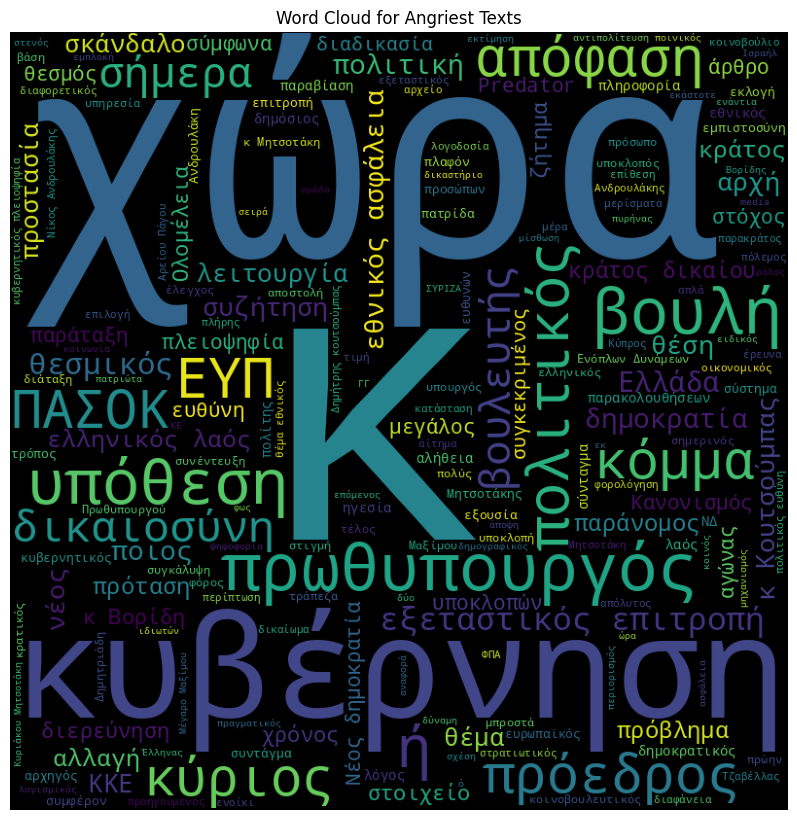

In [41]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Get the full_text of the top 5 angriest articles
angriest_texts = short_tanea_df.sort_values(by='anger', ascending=False).head(5)['full_text']

# Perform lemmatization on the angriest texts, excluding all verbs
lemmatized_angriest_texts = []
for text in angriest_texts:
    doc = nlp(text)
    # Exclude punctuation, spaces, and all verbs
    lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space and token.pos_ != 'VERB']
    lemmatized_angriest_texts.append(' '.join(lemmas))

# Concatenate all lemmatized texts into a single string
all_angriest_text = ' '.join(lemmatized_angriest_texts)

# Generate the word cloud
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='black',
                stopwords = nlp.Defaults.stop_words,
                min_font_size = 10).generate(all_angriest_text)

# Display the word cloud
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.title('Word Cloud for Angriest Texts') # Added title
plt.tight_layout(pad = 0)
plt.show()

In [35]:
print("\nTop 5 fearest texts:")
display(short_tanea_df.sort_values(by='fear', ascending=False).head(5)[['full_text', 'fear']])


Top 5 fearest texts:


,full_text,fear
date,,
2026-05-22 10:31:00,"Καταψηφίστηκε η πρόταση του ΠΑΣΟΚστη Βουλή, κα...",90
2026-04-29 09:33:00,"Ο πρόεδρος του ΠΑΣΟΚ,Νίκος Ανδρουλάκης,παραχώρ...",49
2026-03-17 20:49:00,Χειμαρρώδης και αποκαλυπτικός οΔημήτρης Κουτσο...,35
2026-03-31 15:57:00,Η προ ημερήσιας συζήτηση στηΒουλήγια το Κράτος...,33
2026-03-04 13:09:00,"Επιστολή στον πρόεδρο της Βουλής, Νικήτα Κακλα...",32


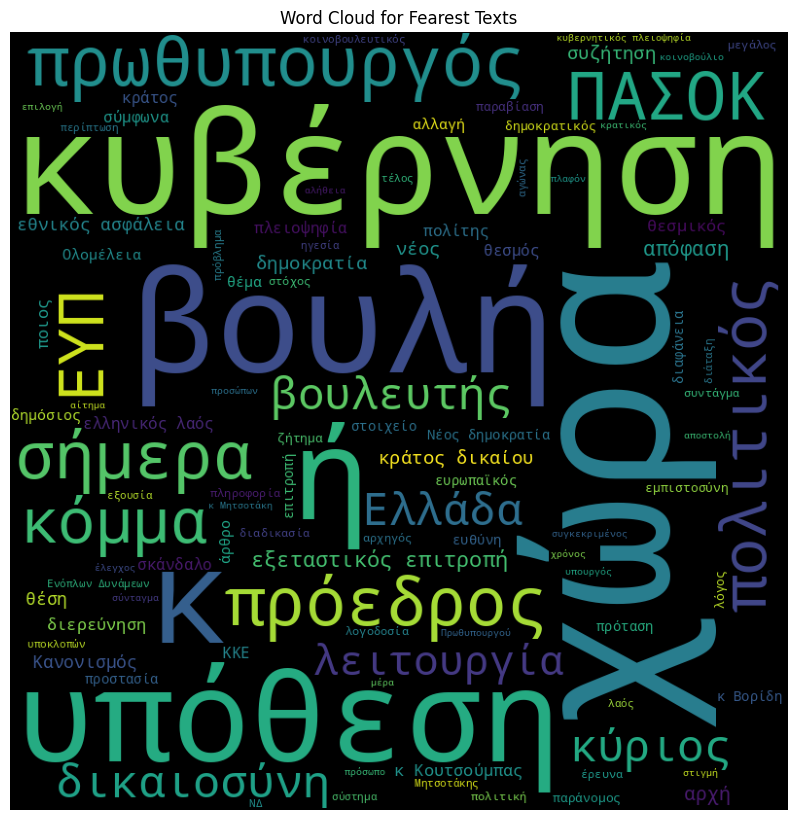

In [44]:
import matplotlib.pyplot as plt

# Get the full_text of the top 5 fearest articles
fearest_texts = short_tanea_df.sort_values(by='fear', ascending=False).head(5)['full_text']

# Perform lemmatization on the fearest texts, excluding all verbs
lemmatized_fearest_texts = []
for text in fearest_texts:
    doc = nlp(text)
    # Exclude punctuation, spaces, and all verbs
    lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space and token.pos_ != 'VERB']
    lemmatized_fearest_texts.append(' '.join(lemmas))

# Concatenate all lemmatized texts into a single string
all_fearest_text = ' '.join(lemmatized_fearest_texts)

# Generate the word cloud
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='black',
                stopwords = nlp.Defaults.stop_words,
                min_font_size = 10).generate(all_fearest_text) # Corrected to all_fearest_text

# Display the word cloud
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.title('Word Cloud for Fearest Texts') # Added title
plt.tight_layout(pad = 0)
plt.savefig('fear_tanea.png')
plt.show()

In [38]:
print("\nTop 5 text with disgust:")
display(short_tanea_df.sort_values(by='disgust', ascending=False).head(5)[['full_text', 'disgust']])


Top 5 text with disgust:


,full_text,disgust
date,,
2026-05-22 10:31:00,"Καταψηφίστηκε η πρόταση του ΠΑΣΟΚστη Βουλή, κα...",54
2026-04-29 09:33:00,"Ο πρόεδρος του ΠΑΣΟΚ,Νίκος Ανδρουλάκης,παραχώρ...",47
2026-03-17 20:49:00,Χειμαρρώδης και αποκαλυπτικός οΔημήτρης Κουτσο...,23
2026-02-06 13:29:00,Τις ποινικές και θεσμικές διαστάσεις της υπόθε...,21
2026-03-29 11:24:00,Αρχικά ο κ. Γεωργιάδης εξέφρασε τα συλλυπητήρι...,20


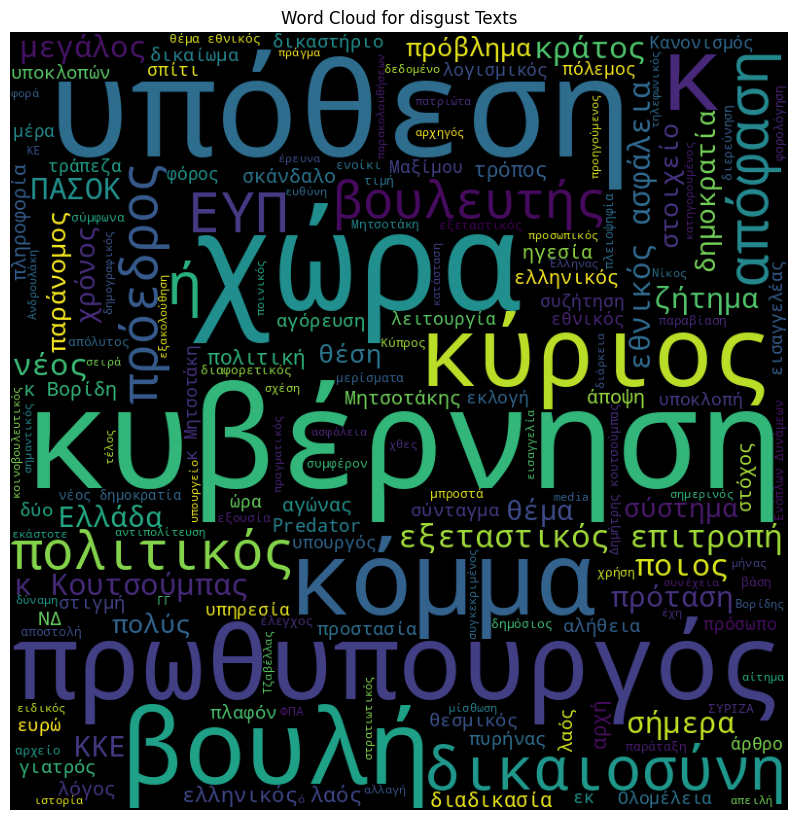

In [43]:
import matplotlib.pyplot as plt

# Get the full_text of the top 5 disgust articles
disgust_texts = short_tanea_df.sort_values(by='disgust', ascending=False).head(5)['full_text']

# Perform lemmatization on the disgust texts, excluding all verbs
lemmatized_disgust_texts = []
for text in disgust_texts:
    doc = nlp(text)
    # Exclude punctuation, spaces, and all verbs
    lemmas = [token.lemma_ for token in doc if not token.is_punct and not token.is_space and token.pos_ != 'VERB']
    lemmatized_disgust_texts.append(' '.join(lemmas))

# Concatenate all lemmatized texts into a single string
all_disgust_text = ' '.join(lemmatized_disgust_texts)

# Generate the word cloud
wordcloud = WordCloud(width = 800, height = 800,
                background_color ='black',
                stopwords = nlp.Defaults.stop_words,
                min_font_size = 10).generate(all_disgust_text)

# Display the word cloud
plt.figure(figsize = (8, 8), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off")
plt.title('Word Cloud for disgust Texts') # Added title
plt.tight_layout(pad = 0)
plt.savefig('disgust_tanea.png')
plt.show()